# The Mandelbrot Set

## Mini-project step 1: Naive, NumPy, Numba

### 1. The Problem
This project focuses on computing and visualizing the Mandelbrot set, which is a "Famous fractal discovered by Benoit Mandelbrot (1980)" (NSC_26_Mandelbrot_Set, Slide 2). It is a "Mathematical set in complex plane" (NSC_26_Mandelbrot_Set, Slide 2) that exhibits "Beautiful self-similar patterns" and "Infinite detail at any zoom level" (NSC_26_Mandelbrot_Set, Slide 2).

The set is defined by the quadratic complex mapping "$z_{i+1}=z_{i}^{2}+c$ $i=0,1,...,I-1$" (Mandelbrot_Set_Description_2022, Slide 3), where the initial condition is $z_{0}=0+j\cdot0$. A complex point $c$ is considered part of the Mandelbrot set if $|z_{n+1}|$ remains bounded as $n\rightarrow\infty$. In practice, we use a threshold because "Threshold $|z|>2$ guarantees divergence" (NSC_26_Mandelbrot_Set, Slide 3).

We map the computational domain over the "region: $x\in[-2,1]$, $y\in[-1.5,1.5]$" (NSC_26_Mandelbrot_Set, Slide 3). For visualization, we use the linear mapping $\mathcal{M}(c)=\frac{l(c)}{I}$, where a smaller value indicates a highly unstable point and a value of 1 indicates a stable point. This specific problem is chosen because it belongs to "Embarrassingly Parallel Problems" where "Each pixel independent" (NSC_26_Mandelbrot_Set, Slide 4).

### 2.1 Naive Implementation
The first approach is the naive version, which utilizes "Pure python nested loops" (NSC_26_MiniProject_I_Guidelines, Slide 8). For each grid point $c$, we initialize $z_{0}=0$ and iterate up to the maximum number of iterations. If the absolute value exceeds the threshold of 2, the point escapes, and we break the loop to move to the next point.

In [1]:
import numpy as np
import time

def mandelbrot_naive(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    M = np.zeros((p_im, p_re))
    
    re_step = (re_max - re_min) / (p_re - 1)
    im_step = (im_max - im_min) / (p_im - 1)
    
    for i in range(p_im):
        c_imag = im_min + i * im_step
        
        for j in range(p_re):
            c_real = re_min + j * re_step
            c = complex(c_real, c_imag)
            
            z = 0.0j
            escape_iter = max_iter 
            
            for k in range(max_iter):
                z = z*z + c
                if abs(z) > 2.0:
                    escape_iter = k + 1
                    break
                    
            M[i, j] = escape_iter / max_iter 
            
    return M

Parameters:

In [2]:
# Fixed boundary parameters
re_min, re_max = -2.0, 1.0
im_min, im_max = -1.5, 1.5

# Grid resolution and maximum iterations
p_re, p_im = 500, 500  
max_iter = 100

Performance parameters:

In [3]:
# Execute the naive function and measure execution time
start_time_naive = time.time()
M_naive = mandelbrot_naive(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_naive = time.time()

exec_time_naive = end_time_naive - start_time_naive
print(f"Naive execution time: {exec_time_naive:.4f} seconds")

Naive execution time: 0.6550 seconds


### 2.2 NumPy Vectorized Implementation
To improve performance, we replace the slow scalar loops with a "Vectorized grid" (NSC_26_MiniProject_I_Guidelines, Slide 8). As explained in the lectures, "Vectorization is the process of mapping loop based scalar computations into operations performed on arrays" (NSC_26_Lec01, Slide 35).

To construct our 2D grid of complex numbers efficiently, we utilize NumPy's broadcasting capabilities. "Broadcasting means that Numpy automatically replicates elements along a singleton dimension as needed" (NSC_26_Lec01, Slide 38), which is exactly what we achieve by using `im[:, np.newaxis]`. We use boolean masking to optimize memory and operations, ensuring we only update the points that have not yet escaped the threshold.

In [4]:
def mandelbrot_vectorized(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    re = np.linspace(re_min, re_max, p_re)
    im = np.linspace(im_min, im_max, p_im)
    c = re + 1j * im[:, np.newaxis]
    
    z = np.zeros_like(c)
    M = np.zeros(c.shape, dtype=int)
    
    for k in range(max_iter):
        mask = np.abs(z) <= 2.0
        M[mask] = k + 1
        z[mask] = z[mask]**2 + c[mask]
        
    return M / max_iter

In [5]:
# Execute the vectorized function and measure execution time
start_time_vectorized = time.time()
M_vectorized = mandelbrot_vectorized(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_vectorized = time.time()
exec_time_vectorized = end_time_vectorized - start_time_vectorized
print(f"Vectorized execution time: {exec_time_vectorized:.4f} seconds")

Vectorized execution time: 0.3133 seconds


### 2.3 Numba JIT Implementation
Our final approach leverages Numba to create a "JIT-compiled implementation" (NSC_26_MiniProject_I_Guidelines, Slide 8). This follows the optimization guideline to "Check if time-critical parts can get required performance by using" "numexpr, numba, and PyPy." (NSC_26_Lec02, Slide 28).

Numba "Allows JIT (Just In Time) compilation, which may speed up some computation" (NSC_26_Lec02, Slide 33). By adding the `@jit(nopython=True)` decorator to the naïve python code, the function is compiled into machine code just-in-time, bypassing the standard Python interpreter overhead.

In [6]:
from numba import jit

@jit(nopython=True)
def mandelbrot_numba(re_min, re_max, im_min, im_max, p_re, p_im, max_iter):
    M = np.zeros((p_im, p_re))
    
    re_step = (re_max - re_min) / (p_re - 1)
    im_step = (im_max - im_min) / (p_im - 1)
    
    for i in range(p_im):
        c_imag = im_min + i * im_step
        
        for j in range(p_re):
            c_real = re_min + j * re_step
            c = complex(c_real, c_imag)
            
            z = 0.0j
            escape_iter = max_iter 
            
            for k in range(max_iter):
                z = z*z + c
                if abs(z) > 2.0:
                    escape_iter = k + 1
                    break
                    
            M[i, j] = escape_iter / max_iter 
            
    return M

In [7]:
# Warm-up run to allow Numba to compile the code
_ = mandelbrot_numba(re_min, re_max, im_min, im_max, 10, 10, 10)

# Measure execution time
start_time_nb = time.time()
M_numba = mandelbrot_numba(re_min, re_max, im_min, im_max, p_re, p_im, max_iter)
end_time_nb = time.time()

exec_time_nb = end_time_nb - start_time_nb
print(f"Numba execution time: {exec_time_nb:.4f} seconds")

Numba execution time: 0.0557 seconds


## 3. Performance and Scaling Analysis

To perform a comprehensive scaling analysis, we sweep through gradually increasing grid resolutions.
We measure the execution time for all three implementations (Naive, NumPy, and Numba) at each resolution. 

The timing results are stored in a Pandas DataFrame, exported to a CSV file for submission, and finally visualized using a line chart to clearly illustrate the performance differences and scalability of each approach.

### 3.1 Benchmarking Methodology
Following the golden rule of code optimization, we must "Never ever optimize in the blind - always (!!!) profile before optimizing" (NSC_26_Lec02, Slide 29).

To perform our scaling analysis, we "Start small" and "increase gradually → reach sizes where naive version takes dozens of seconds or even up to a few minutes" (NSC_26_MiniProject_I_Guidelines, Slide 8). We "Measure execution time of all three versions" and "Use consistent parameters" across our benchmarks (NSC_26_MiniProject_I_Guidelines, Slide 8).

The fixed region is $-2\le\mathfrak{R}\{c\}\le1$ and $-1.5\le\mathfrak{I}\{c\}\le1.5$, and we typically use a `max_iter` of 100. A warm-up run is included for the Numba function to ensure compilation time is not included in the final metrics.

In [8]:
import pandas as pd

# Sweep parameter: gradually increasing grid resolutions (N x N)
resolutions = [100, 300, 600, 1000, 1500] 
results = []

print("Starting scaling analysis. This might take a few minutes...")

for N in resolutions:
    print(f"Testing resolution: {N}x{N}")
    
    # 1. Naive
    t0 = time.time()
    _ = mandelbrot_naive(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_naive = time.time() - t0
    
    # 2. NumPy
    t0 = time.time()
    _ = mandelbrot_vectorized(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_numpy = time.time() - t0
    
    # 3. Numba
    t0 = time.time()
    _ = mandelbrot_numba(re_min, re_max, im_min, im_max, N, N, max_iter)
    t_numba = time.time() - t0
    
    # Store results
    results.append({
        'Resolution (NxN)': N,
        'Naive Time (s)': t_naive,
        'NumPy Time (s)': t_numpy,
        'Numba Time (s)': t_numba
    })

# Create DataFrame and export to CSV as required
df_results = pd.DataFrame(results)
df_results.to_csv('timing_results.csv', index=False)

print("\nAnalysis complete! Data saved to 'timing_results.csv'.")
display(df_results)

Starting scaling analysis. This might take a few minutes...
Testing resolution: 100x100
Testing resolution: 300x300
Testing resolution: 600x600
Testing resolution: 1000x1000
Testing resolution: 1500x1500

Analysis complete! Data saved to 'timing_results.csv'.


,Resolution (NxN),Naive Time (s),NumPy Time (s),Numba Time (s)
0,100,0.030171,0.006823,0.002089
1,300,0.211766,0.057101,0.017534
2,600,0.906129,0.223306,0.071247
3,1000,2.368513,0.739151,0.198817
4,1500,5.427422,2.018383,0.424794


### 4. Experimental Results
The graph below plots the execution times of the three implementations as the grid resolution $N$ increases. As observed, the Naive execution time grows exponentially with the problem size, whereas the NumPy and Numba implementations remain significantly flatter, indicating vastly superior scaling.

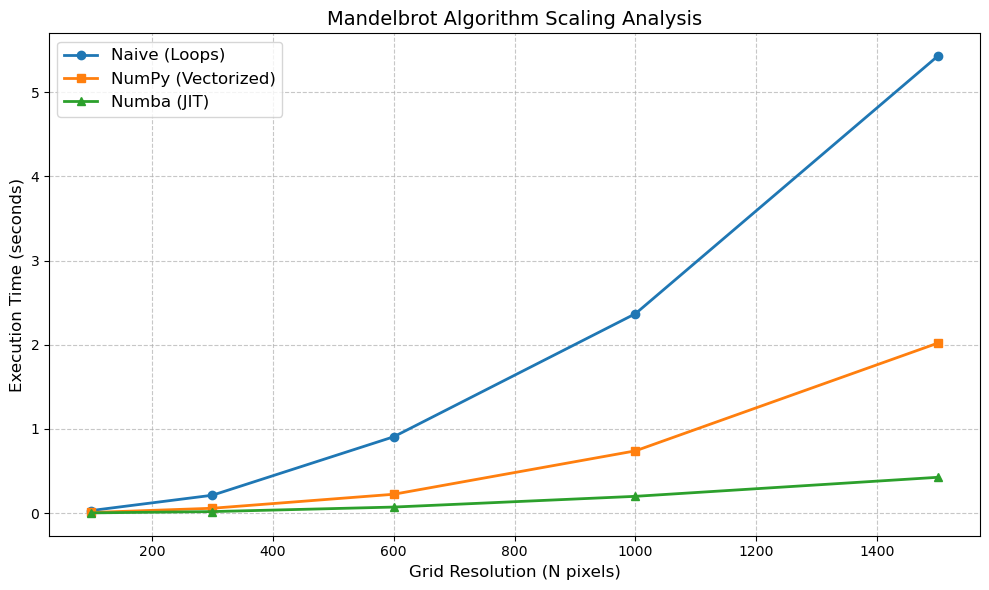

In [9]:
import matplotlib.pyplot as plt

# Plotting the scaling analysis
plt.figure(figsize=(10, 6))

plt.plot(df_results['Resolution (NxN)'], df_results['Naive Time (s)'], marker='o', label='Naive (Loops)', linewidth=2)
plt.plot(df_results['Resolution (NxN)'], df_results['NumPy Time (s)'], marker='s', label='NumPy (Vectorized)', linewidth=2)
plt.plot(df_results['Resolution (NxN)'], df_results['Numba Time (s)'], marker='^', label='Numba (JIT)', linewidth=2)

plt.title('Mandelbrot Algorithm Scaling Analysis', fontsize=14)
plt.xlabel('Grid Resolution (N pixels)', fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

### 5. Reasoning and Interpretation
The performance analysis reveals significant differences between the implementations. The Mandelbrot set is "Computationally intensive" and the "Naive version is slow → need optimization!" (NSC_26_Mandelbrot_Set, Slide 4).

**Interpreter Overhead vs. Hardware Utilization:**
Because "Each pixel independent", this is an embarrassingly parallel problem, making it "Perfect for multiprocessing, GPU, and distributed computing" (NSC_26_Mandelbrot_Set, Slide 4). 

The Naive approach struggles because the Python interpreter must evaluate every operation inside the nested loops dynamically. "Algorithmic intensity describes the amount of floating-point operations relative to the total number of bytes processed by an algorithm" (NSC_26_Lec02, Slide 17). While floating-point operations are critical, "Most modern processors and algorithms lead to memory bound computations" (NSC_26_Lec02, Slide 30) , meaning "the hardware can deliver more floating-point performance than data can be transferred to the ALU(s)" (NSC_26_Lec02, Slide 20).

**Memory Management, Caching, and Locality:**
"Memory access is today the most critical issue for overall computing performance." (NSC_26_Lec01, Slide 26). When the CPU needs data, it checks the fast local L1/L2/L3 caches. "If data is not found in cache, it is a cache miss" (NSC_26_Lec01, Slide 31).

Our NumPy implementation heavily mitigates this by applying boolean masks. By cutting out pixels that have already escaped the threshold, we avoid useless computations and unnecessary memory writes. "This keeps the active working dataset smaller and closer to the CPU, exploiting Temporal Locality so that "the data stays in cache as long as we are using them" (NSC_26_Lec02, Slide 12). It also exploits Spatial Locality by performing contiguous array operations rather than fragmented data fetching, avoiding the penalties of long "Striding: accessing every nth element in memory." (NSC_26_Lec02, Slide 13).

Numba outperforms both by performing JIT compilation. It compiles the nested loops directly into machine code, which allows the CPU to keep intermediate variables (like $z$ and $c$) entirely inside its ultra-fast hardware registers, bypassing the latency of reading and writing to main memory altogether.